###IMPORT NECESSARY LIBRARIES

In [2]:
!pip install pandas matplotlib seaborn openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###LOAD THE DATA

In [3]:
from google.colab import files
import io
uploaded = files.upload()
import pandas as pd
df = pd.read_excel(io.BytesIO(uploaded[list(uploaded.keys())[0]]))
print("Shape of dataset:", df.shape)
df.head()

Saving 1730285881-Airbnb_Open_Data.xlsx to 1730285881-Airbnb_Open_Data.xlsx
Shape of dataset: (102599, 26)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

The columns within the dataset are mentioned.

###MISSING VALUES IN DATASET

In [5]:
print(df.isnull().sum())

id                                     0
NAME                                 270
host id                                0
host_identity_verified               289
host name                            408
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

###HANDLE MISSING VALUES
1. Convert 'last review' to datetime and handle errors
2. Fill missing values
3. Drop records with missing 'name' or 'host name'

In [6]:
# Convert 'last review' to datetime and handle errors
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')
# Fill missing values
df.fillna({'reviews per month': 0, 'last review': df['last review'].min()}, inplace=True)
# Drop records with missing 'name' or 'host name'
df.dropna(subset=['NAME', 'host name'], inplace=True)

###CORRECT THE DATA TYPES

Remove the dollar signs in 'price' column and convert the datatype to float

In [7]:
# Remove dollar signs and convert to float
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-138066982.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipython-input-138066982.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)


###REMOVE THE DUPLICATES

In [8]:
df.drop_duplicates(inplace=True)

###DATA CLEANING

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 101388 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101388 non-null  int64         
 1   NAME                            101388 non-null  object        
 2   host id                         101388 non-null  int64         
 3   host_identity_verified          101112 non-null  object        
 4   host name                       101388 non-null  object        
 5   neighbourhood group             101362 non-null  object        
 6   neighbourhood                   101372 non-null  object        
 7   lat                             101380 non-null  float64       
 8   long                            101380 non-null  float64       
 9   country                         100862 non-null  object        
 10  country code                    101266 non-null  object      

###**EXPLORATORY DATA ANALYSIS**
###SUMMARY STATISTICS
1. Count → Number of non-null values in each column

2. Mean → Average value (numerical columns)

3. Std → Standard deviation (spread of the data)

4. Min, 25%, 50%, 75%, Max → Distribution of numerical values (quartiles)

In [10]:
print(df.describe())

                 id       host id            lat           long  \
count  1.013880e+05  1.013880e+05  101380.000000  101380.000000   
mean   2.921061e+07  4.925888e+10      40.728079     -73.949664   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.507767e+07  2.458873e+10      40.688720     -73.982570   
50%    2.922911e+07  4.911887e+10      40.722310     -73.954440   
75%    4.328611e+07  7.399645e+10      40.762750     -73.932340   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   
std    1.626815e+07  2.853654e+10       0.055851       0.049470   

       instant_bookable  Construction year          price    service fee  \
count     101292.000000      101188.000000  101149.000000  101120.000000   
mean           0.497887        2012.486332     625.378303     125.043463   
min            0.000000        2003.000000      50.000000      10.000000   
25%            0.000000        2007.000000     340.000000      68.000000   
50%            0

###1. ROOM TYPES IN THE DATASET

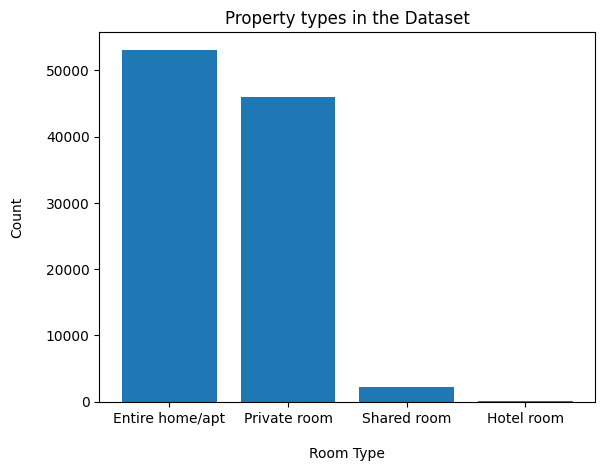

In [20]:
room_type=plt.bar(df['room type'].value_counts().index,df['room type'].value_counts().values)
plt.title('Property types in the Dataset')
plt.xlabel('\nRoom Type')
plt.ylabel('Count\n')
plt.show()

####The Airbnb Data consists of 4 room types which are : Entire home/apt, Private room, Shared room, Hotel room. The Entire home/apt dominates the dataset with more than 50000 occurences

###2. NUMBER OF LISTINGS BY NEIGHBORHOOD GROUP

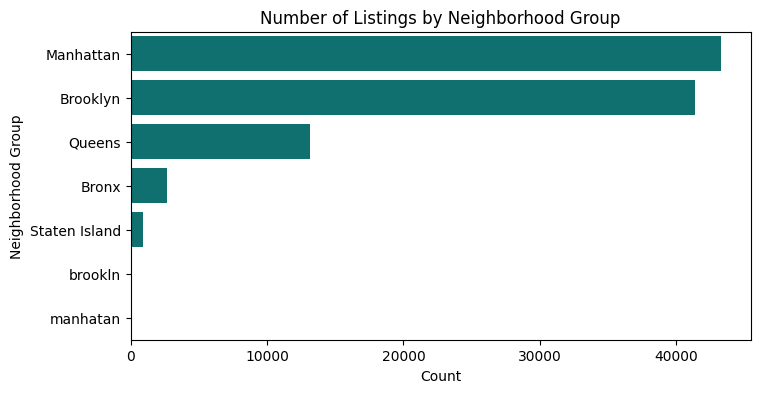

In [12]:
plt.figure(figsize=(8, 4))
sns.countplot(y='neighbourhood group', data=df,color="teal" , order=df['neighbourhood group'].value_counts().index)
plt.title('Number of Listings by Neighborhood Group')
plt.xlabel('Count')
plt.ylabel('Neighborhood Group')
plt.show()

It highlights how listings are distributed among the neighborhood groups. Some areas (like Manhattan and Brooklyn) dominate with the highest number of listings, reflecting their popularity for both tourists and hosts. Other groups (such as Queens, Bronx, and Staten Island) have significantly fewer listings, showing they are less preferred locations compared to the central and well-connected areas.

###3. PRICES VS NEIGHBORHOOD GROUP

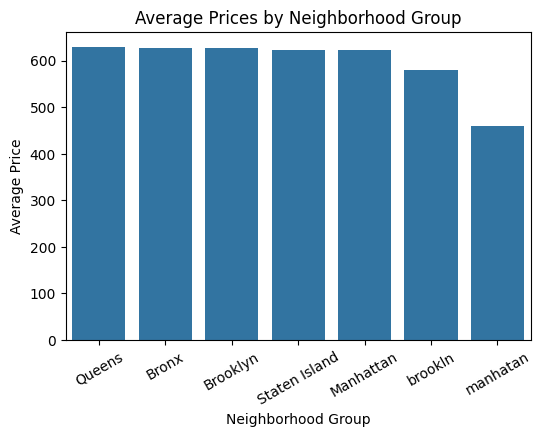

Average prices:
 neighbourhood group
Queens           630.019332
Bronx            627.634219
Brooklyn         626.475460
Staten Island    623.314894
Manhattan        622.810819
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64


In [40]:
avg_prices = df.groupby("neighbourhood group")["price"].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=avg_prices.index, y=avg_prices.values)
plt.title("Average Prices by Neighborhood Group")
plt.xlabel("Neighborhood Group")
plt.ylabel("Average Price")
plt.xticks(rotation=30)
plt.show()
print("Average prices:\n", avg_prices)

###4. RELATION BETWEEN CONSTRUCTION YEAR VS PRICE

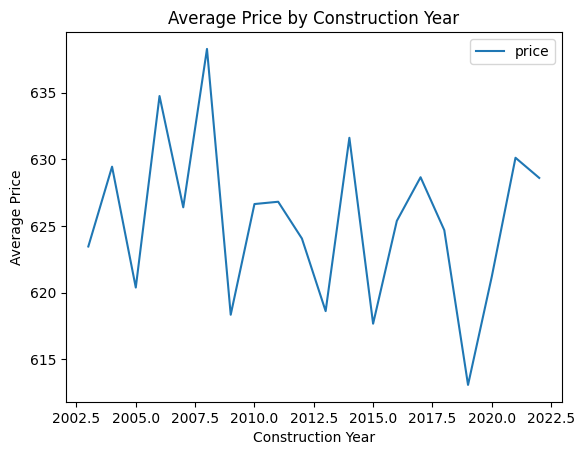

In [14]:
df.groupby(df['Construction year'])['price'].mean().to_frame().plot();
plt.xlabel('Construction Year')
plt.ylabel('Average Price')
plt.title('Average Price by Construction Year')
plt.show()

The graph shows how the average price of listings varies with the construction year. It helps identify whether newer or older properties tend to have higher average prices. Fluctuations across years may highlight demand for modern accommodations or the historical appeal of older constructions

###5. TOP 10 HOSTS

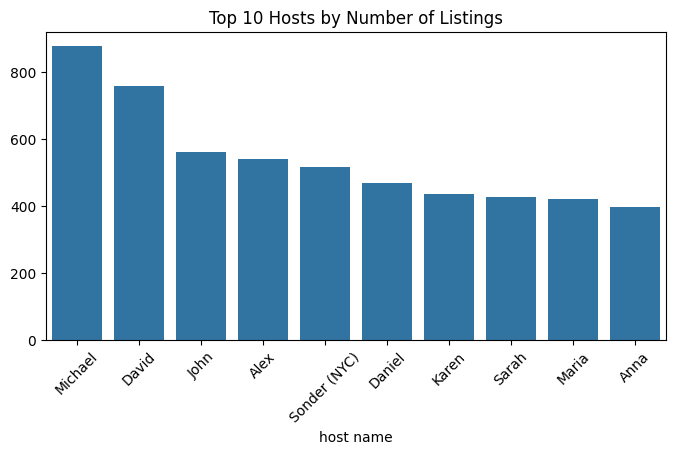

Top 10 hosts:
 host name
Michael         877
David           759
John            562
Alex            541
Sonder (NYC)    515
Daniel          468
Karen           436
Sarah           428
Maria           420
Anna            396
Name: count, dtype: int64


In [15]:
top_hosts = df["host name"].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_hosts.index.astype(str), y=top_hosts.values)
plt.title("Top 10 Hosts by Number of Listings")
plt.xticks(rotation=45)
plt.show()
print("Top 10 hosts:\n", top_hosts)

The visualization highlights hosts dominate the market with the highest number of properties listed. Some hosts manage a significantly larger portfolio like Michael - 877, David - 759, suggesting they are professional hosts or property managers.

###6. ARE HOSTS WITH VERIFIED IDENTITIES MORE LIKELY TO RECEIVE POSITIVE REVIEWS ?

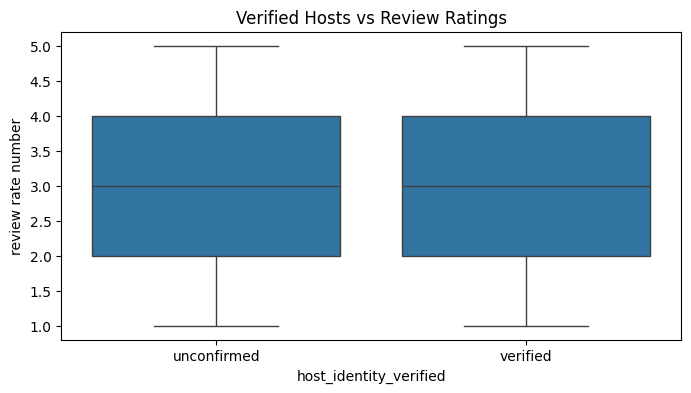

                        review rate number
host_identity_verified                    
verified                          3.285048
unconfirmed                       3.271954


In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="host_identity_verified", y="review rate number")
plt.title("Verified Hosts vs Review Ratings")
plt.show()
print(df.groupby("host_identity_verified")["review rate number"].mean().sort_values(ascending=False).to_frame())

###7. CORRELATION BETWEEN PRICE OF LISTING AND ITS SERVICE FEE

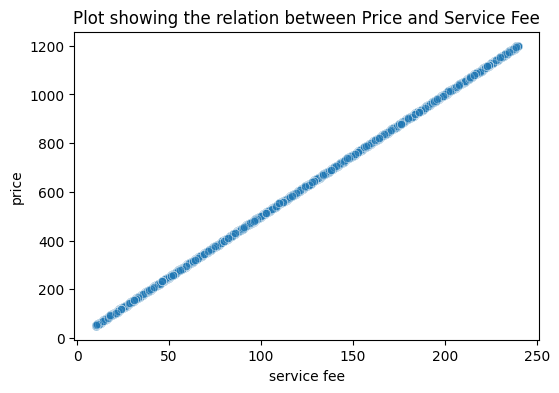

                price  service fee
price        1.000000     0.999991
service fee  0.999991     1.000000


In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="service fee", y="price", alpha=0.5)
plt.title("Plot showing the relation between Price and Service Fee")
plt.show()
print(df[["price", "service fee"]].corr())

###8. AVERAGE REVIEW RATE NUMBER FOR LISTINGS

In [23]:
avg_reviews=df.groupby(['neighbourhood group','room type'])['review rate number'].mean().to_frame()
avg_reviews

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.347222
                    Private room               3.326200
                    Shared room                3.306306
Brooklyn            Entire home/apt            3.249175
                    Hotel room                 3.857143
                    Private room               3.263454
                    Shared room                3.336996
Manhattan           Entire home/apt            3.276026
                    Hotel room                 3.500000
                    Private room               3.278051
                    Shared room                3.256757
Queens              Entire home/apt            3.347809
                    Hotel room                 3.750000
                    Private room               3.313402
                    Shared room                3.369748
Staten Island       Entire home/apt            3.329787
                    Private room               3.476821
                    Shared room                3.428571
brookln             Private room               4.000000
manhatan            Private room               3.000000

Text(0.5, 1.0, 'Average Review Rate Number by Neighbourhood Group and Room Type')

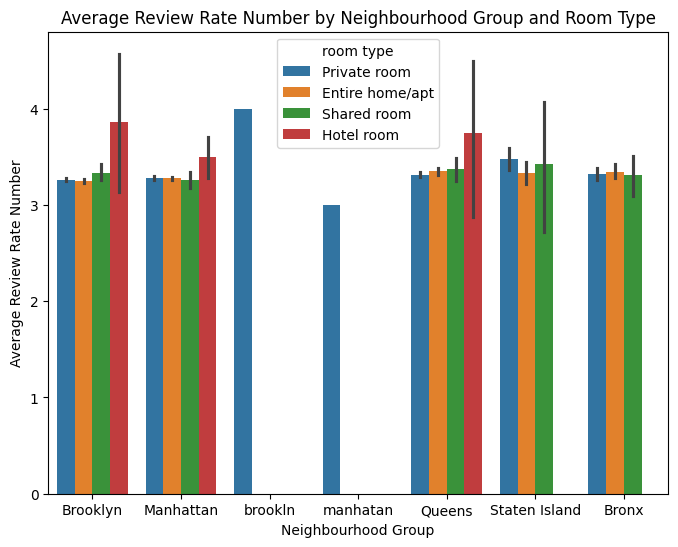

In [27]:
plt.figure(figsize=[8,6])
sns.barplot(data=df, x='neighbourhood group', y='review rate number', hue='room type')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Review Rate Number')
plt.title('Average Review Rate Number by Neighbourhood Group and Room Type')

###9. ARE HOSTS WITH HIGHER CALCULATED HOST RATINGS COUNT MORE LIKELY TO MAINTAIN HIGHER AVAILABILITY THROUGHOUT THE YEAR ?

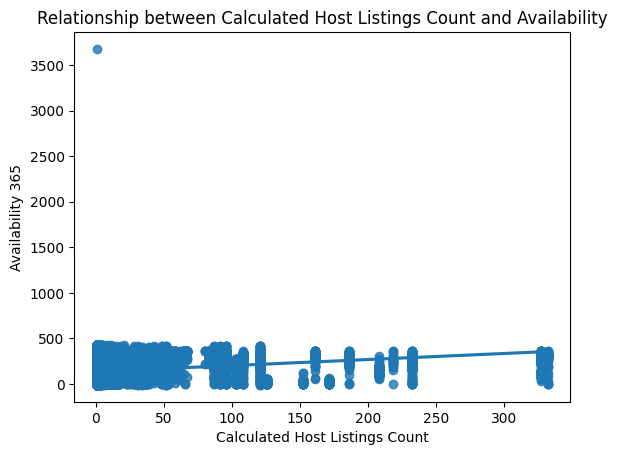

In [28]:
sns.regplot(df,x = 'calculated host listings count', y = 'availability 365')
plt.xlabel('Calculated Host Listings Count')
plt.ylabel('Availability 365')
plt.title('Relationship between Calculated Host Listings Count and Availability')
plt.show()

In [29]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.15884308755866242)

###**CONCLUSION** :
The analysis revealed that entire homes/apartments and private rooms are the most popular room types, while key neighborhoods dominate listings and average prices. Verified hosts generally receive higher ratings, and price shows a positive correlation with service fees. Availability trends and host listing counts highlighted the presence of both casual and professional hosts. Overall, the project provides clear insights into Airbnb market patterns, customer preferences, and host strategies.